In [1]:
import pybamm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Load database and create virtual cell

In [3]:
param_li = pybamm.ParameterValues("Chen2020")       # Lithium (Commercial 5Ah)
param_na = pybamm.ParameterValues("Chayambuka2022") # Sodium (Laboratory Coin cell)

# Create the Virtual Cell by copying the sodium parameters...
param_na_virtual = pybamm.ParameterValues("Chayambuka2022")

# ...and overwriting the macro-geometry with the lithium one
macro_parameters = [
    "Nominal cell capacity [A.h]",
    "Electrode height [m]",
    "Electrode width [m]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",
    "Positive electrode thickness [m]",
    "Number of electrodes connected in parallel to make a cell",
    "Cell volume [m3]",
    "Cell cooling surface area [m2]"
]

for p in macro_parameters:
    param_na_virtual[p] = param_li[p]

# Set the chosen cut-off for the dataset
param_na_virtual["Lower voltage cut-off [V]"] = 2.0

Data extraction and formatting

In [4]:
keys_to_compare = [
    "Lower voltage cut-off [V]",
    "Nominal cell capacity [A.h]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",
    "Positive electrode thickness [m]",
    "Negative electrode porosity",
    "Positive electrode porosity",
    "Negative particle radius [m]",
    "Positive particle radius [m]"
]

data = []
for key in keys_to_compare:
    try:
        val_li = param_li[key]
        val_na = param_na[key]
        val_virtual = param_na_virtual[key]
        
        # Helper function to format numbers
        def format_val(v):
            if isinstance(v, (int, float)):
                return f"{v:.4e}" if v < 0.01 else f"{v:.4f}"
            return str(v)
            
        data.append([key, format_val(val_li), format_val(val_na), format_val(val_virtual)])
    except KeyError:
        data.append([key, "Not Found", "Not Found", "Not Found"])

df = pd.DataFrame(data, columns=["Physical Parameter", "Lithium (Chen2020)", "Sodium (Chayambuka2022)", "Sodium (Virtual Cell)"])

print("\n" + "="*105)
print("   GEOMETRIC AND CAPACITY COMPARISON: LITHIUM vs SODIUM vs VIRTUAL CELL")
print("="*105)
print(df.to_string(index=False, justify='left'))
print("="*105 + "\n")


   GEOMETRIC AND CAPACITY COMPARISON: LITHIUM vs SODIUM vs VIRTUAL CELL
Physical Parameter               Lithium (Chen2020) Sodium (Chayambuka2022) Sodium (Virtual Cell)
       Lower voltage cut-off [V]     2.5000             2.0000                  2.0000           
     Nominal cell capacity [A.h]     5.0000         3.0000e-03                  5.0000           
Negative electrode thickness [m] 8.5200e-05         6.4000e-05              8.5200e-05           
         Separator thickness [m] 1.2000e-05         2.5000e-05              1.2000e-05           
Positive electrode thickness [m] 7.5600e-05         6.8000e-05              7.5600e-05           
     Negative electrode porosity     0.2500             0.5100                  0.5100           
     Positive electrode porosity     0.3350             0.2300                  0.2300           
    Negative particle radius [m] 5.8600e-06         3.4800e-06              3.4800e-06           
    Positive particle radius [m] 5.2200e-06  

Geometric visualization

Generating geometry plot...


<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
C:\Users\angel\AppData\Local\Temp\ipykernel_12468\2314994397.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Cell Thickness [$\mu m$]', fontsize=12, fontweight='bold')


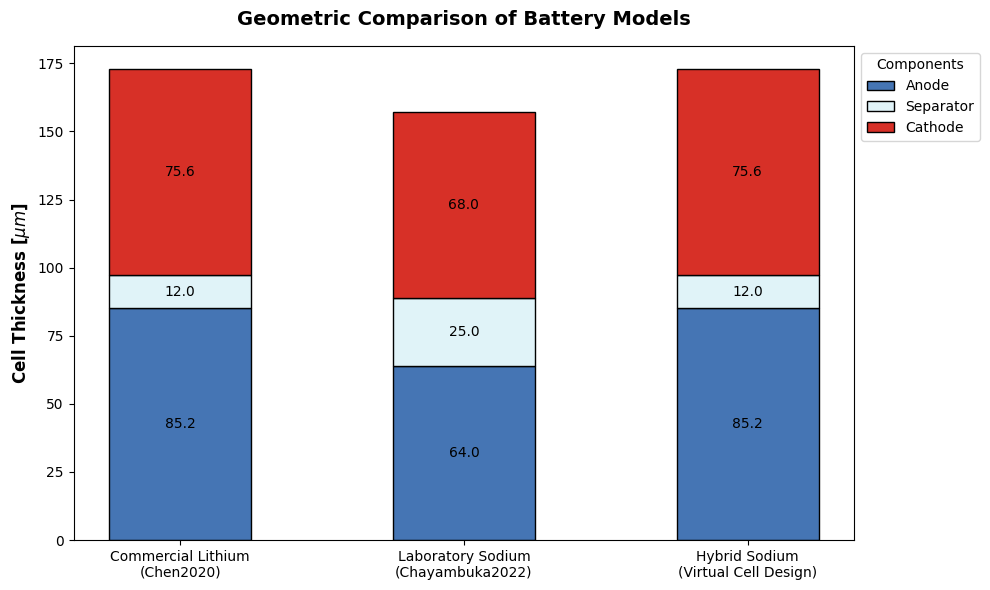

In [7]:
print("Generating geometry plot...")

# Extract thicknesses and convert to micrometers (multiply by 1e6)
def get_thicknesses(param_set):
    anode = param_set["Negative electrode thickness [m]"] * 1e6
    sep = param_set["Separator thickness [m]"] * 1e6
    cathode = param_set["Positive electrode thickness [m]"] * 1e6
    return anode, sep, cathode

thick_li = get_thicknesses(param_li)
thick_na = get_thicknesses(param_na)
thick_virtual = get_thicknesses(param_na_virtual)

# Plot setup
labels = ['Commercial Lithium\n(Chen2020)', 'Laboratory Sodium\n(Chayambuka2022)', 'Hybrid Sodium\n(Virtual Cell Design)']
anode_vals = [thick_li[0], thick_na[0], thick_virtual[0]]
sep_vals = [thick_li[1], thick_na[1], thick_virtual[1]]
cathode_vals = [thick_li[2], thick_na[2], thick_virtual[2]]

width = 0.5  # bar width
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the stacked bars
p1 = ax.bar(labels, anode_vals, width, label='Anode', color='#4575b4', edgecolor='black')
p2 = ax.bar(labels, sep_vals, width, bottom=anode_vals, label='Separator', color='#e0f3f8', edgecolor='black')
p3 = ax.bar(labels, cathode_vals, width, bottom=np.array(anode_vals)+np.array(sep_vals), label='Cathode', color='#d73027', edgecolor='black')

# Decorations
ax.set_ylabel('Cell Thickness [$\mu m$]', fontsize=12, fontweight='bold')
ax.set_title('Geometric Comparison of Battery Models', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Components', loc='upper left', bbox_to_anchor=(1, 1))

# Add text annotations inside the bars for better readability
for rects in [p1, p2, p3]:
    for rect in rects:
        height = rect.get_height()
        if height > 5:  # Do not print text if the bar is too thin
            ax.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2),
                        xytext=(0, 0),  
                        textcoords="offset points",
                        ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()